In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("players_data_light-2024_2025.csv")

print(df.shape)
print(df.head())
print(df.info())

(2854, 165)
   Rk             Player   Nation    Pos        Squad                Comp  \
0   1         Max Aarons  eng ENG     DF  Bournemouth  eng Premier League   
1   2         Max Aarons  eng ENG  DF,MF     Valencia          es La Liga   
2   3     Rodrigo Abajas   es ESP     DF     Valencia          es La Liga   
3   4     James Abankwah   ie IRL  DF,MF      Udinese          it Serie A   
4   5  Keyliane Abdallah   fr FRA     FW    Marseille          fr Ligue 1   

    Age    Born  MP  Starts  ...  Att (GK)  Thr  Launch%  AvgLen  Opp  Stp  \
0  24.0  2000.0   3       1  ...       NaN  NaN      NaN     NaN  NaN  NaN   
1  24.0  2000.0   4       1  ...       NaN  NaN      NaN     NaN  NaN  NaN   
2  21.0  2003.0   1       1  ...       NaN  NaN      NaN     NaN  NaN  NaN   
3  20.0  2004.0   6       0  ...       NaN  NaN      NaN     NaN  NaN  NaN   
4  18.0  2006.0   1       0  ...       NaN  NaN      NaN     NaN  NaN  NaN   

   Stp%  #OPA  #OPA/90  AvgDist  
0   NaN   NaN      NaN

In [5]:
print(df.columns.tolist())
print(df.isnull().sum().sort_values(ascending=False).head(20))
print(df.describe())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'G+A-PK', 'xG+xAG', 'PrgC', 'PrgP', 'PrgR', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'PK_stats_shooting', 'PKatt_stats_shooting', 'xG_stats_shooting', 'npxG_stats_shooting', 'npxG/Sh', 'G-xG', 'np:G-xG', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'Ast_stats_passing', 'xAG_stats_passing', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'PrgP_stats_passing', 'Live', 'Dead', 'FK_stats_passing_types', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Cmp_stats_passing_types', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att_stats_defense', 'Tkl%', 'Lost', 'Blocks_stats_defense', 'Sh_stats_defense', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'SCA', 'SCA90', 'PassLive', 'PassDead', 'TO', 'Sh_stats_gca', 'Fld', 'Def', 'GCA', 'GCA90', 'Touches', 'Def Pen', 'Def 3rd_stats_possess

In [8]:
cols = [
    "Player", "Nation", "Pos", "Squad", "Comp", "Age",
    "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A",
    "xG", "xAG", "G-xG",
    "Sh", "SoT", "SoT%",
    "PrgC", "PrgP", "PrgR",
    "Cmp%", "Tkl", "Int", "Tkl+Int"
]

data = df[cols].copy()

print(data.shape)
data.head()

(2854, 26)


,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,90s,...,Sh,SoT,SoT%,PrgC,PrgP,PrgR,Cmp%,Tkl,Int,Tkl+Int
0,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,3,1,86,1.0,...,0,0,NaN,1,8,3,79.4,2,1,3
1,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,4,1,120,1.3,...,0,0,NaN,0,6,10,71.2,4,0,4
2,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,1,1,65,0.7,...,1,0,0.0,3,2,3,58.6,3,1,4
3,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,6,0,88,1.0,...,1,0,0.0,3,4,1,78.3,4,1,5
4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,1,0,3,0.0,...,0,0,NaN,1,0,0,100.0,1,0,1


In [9]:
data_900 = data[data["Min"] >= 900].copy()

print(data_900.shape)
data_900.head()

(1570, 26)


,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,90s,...,Sh,SoT,SoT%,PrgC,PrgP,PrgR,Cmp%,Tkl,Int,Tkl+Int
5,Yunis Abdelhamid,ma MAR,DF,Saint-Étienne,fr Ligue 1,36.0,16,11,1033,11.5,...,2,1,50.0,4,22,3,86.7,17,14,31
6,Himad Abdelli,dz ALG,"MF,FW",Angers,fr Ligue 1,24.0,32,32,2842,31.6,...,35,8,22.9,107,207,111,82.1,48,26,74
8,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,30.0,25,17,1393,15.5,...,29,11,37.9,35,42,101,74.0,43,20,63
10,Abel,es ESP,DF,Osasuna,es La Liga,23.0,35,20,2074,23.0,...,12,4,33.3,50,77,92,72.5,61,18,79
13,Matthis Abline,fr FRA,FW,Nantes,fr Ligue 1,21.0,34,33,2768,30.8,...,73,26,35.6,75,48,169,65.2,11,4,15


In [10]:
data_900["G_minus_xG"] = data_900["Gls"] - data_900["xG"]

over_xg = data_900.sort_values("G_minus_xG", ascending=False).head(10)

over_xg[["Player", "Squad", "Comp", "Pos", "Min", "Gls", "xG", "G_minus_xG"]]

,Player,Squad,Comp,Pos,Min,Gls,xG,G_minus_xG
2369,Patrik Schick,Leverkusen,de Bundesliga,FW,1684,21,12.7,8.3
1693,Bryan Mbeumo,Brentford,eng Premier League,FW,3414,20,12.3,7.7
2787,Chris Wood,Nott'ham Forest,eng Premier League,FW,2959,20,13.4,6.6
637,Matheus Cunha,Wolves,eng Premier League,"MF,FW",2597,15,8.6,6.4
2088,Ayoze Pérez,Villarreal,es La Liga,FW,1970,19,12.7,6.3
1631,Omar Marmoush,Eint Frankfurt,de Bundesliga,FW,1448,15,8.8,6.2
2201,Mateo Retegui,Atalanta,it Serie A,FW,2383,25,18.9,6.1
1317,Harry Kane,Bayern Munich,de Bundesliga,FW,2381,26,20.3,5.7
2324,Oihan Sancet,Athletic Club,es La Liga,MF,1620,15,9.7,5.3
1691,Kylian Mbappé,Real Madrid,es La Liga,FW,2907,31,25.9,5.1


In [11]:
top_scorer = data_900.sort_values("Gls", ascending=False).head(10)

top_scorer[["Player", "Squad", "Comp", "Pos", "Min", "Gls", "Ast", "xG"]]

,Player,Squad,Comp,Pos,Min,Gls,Ast,xG
1691,Kylian Mbappé,Real Madrid,es La Liga,FW,2907,31,3,25.9
2304,Mohamed Salah,Liverpool,eng Premier League,FW,3371,29,18,25.2
1483,Robert Lewandowski,Barcelona,es La Liga,FW,2667,27,2,27.1
1317,Harry Kane,Bayern Munich,de Bundesliga,FW,2381,26,9,20.3
2201,Mateo Retegui,Atalanta,it Serie A,FW,2383,25,8,18.9
1219,Alexander Isak,Newcastle Utd,eng Premier League,FW,2756,23,6,20.3
1109,Erling Haaland,Manchester City,eng Premier League,FW,2736,22,3,22.0
1060,Mason Greenwood,Marseille,fr Ligue 1,"FW,MF",2804,21,5,16.3
405,Ante Budimir,Osasuna,es La Liga,FW,2952,21,4,18.3
697,Ousmane Dembélé,Paris S-G,fr Ligue 1,FW,1730,21,6,16.6


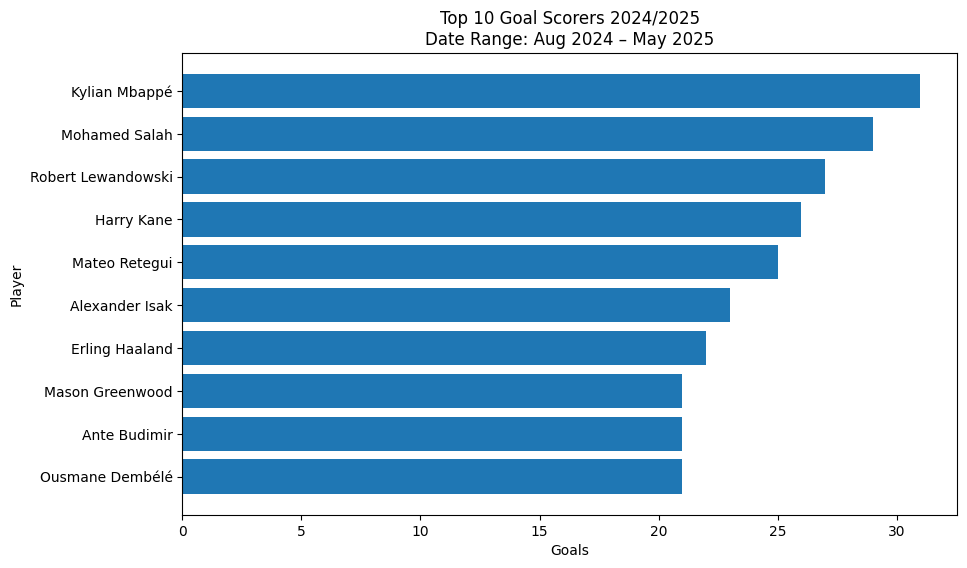

In [13]:
import matplotlib.pyplot as plt

top_scorer = data_900.sort_values("Gls", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_scorer["Player"], top_scorer["Gls"])
plt.xlabel("Goals")
plt.ylabel("Player")
plt.title("Top 10 Goal Scorers 2024/2025\nDate Range: Aug 2024 – May 2025")
plt.gca().invert_yaxis()
plt.show()

### TopAssists

In [14]:
top_assist = data_900.sort_values("Ast", ascending=False).head(10)

top_assist[["Player", "Squad", "Comp", "Pos", "Min", "Ast", "xAG"]]

,Player,Squad,Comp,Pos,Min,Ast,xAG
2304,Mohamed Salah,Liverpool,eng Premier League,FW,3371,18,14.2
1960,Michael Olise,Bayern Munich,de Bundesliga,"FW,MF",2334,15,12.0
2792,Lamine Yamal,Barcelona,es La Liga,FW,2856,13,13.9
2779,Florian Wirtz,Leverkusen,de Bundesliga,"MF,FW",2351,12,7.0
1830,Jacob Murphy,Newcastle Utd,eng Premier League,FW,2360,12,8.9
1064,Vincenzo Grifo,Freiburg,de Bundesliga,"FW,MF",2432,11,6.9
829,Anthony Elanga,Nott'ham Forest,eng Premier League,"FW,MF",2501,11,5.7
541,Rayan Cherki,Lyon,fr Ligue 1,"FW,MF",2041,11,11.1
2099,Gaëtan Perrin,Auxerre,fr Ligue 1,"MF,FW",2691,11,7.8
66,Maghnes Akliouche,Monaco,fr Ligue 1,"FW,MF",2406,10,7.3


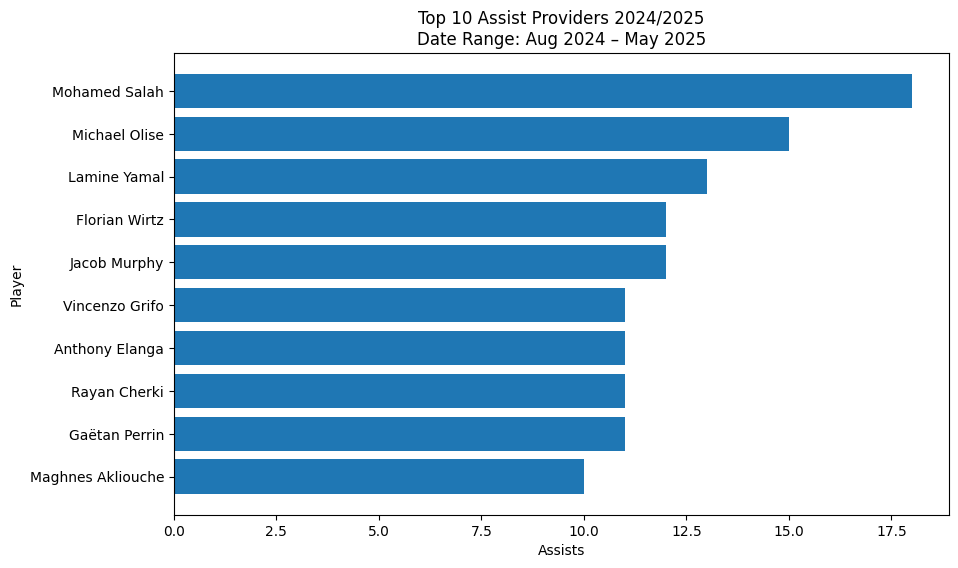

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(top_assist["Player"], top_assist["Ast"])
plt.xlabel("Assists")
plt.ylabel("Player")
plt.title("Top 10 Assist Providers 2024/2025\nDate Range: Aug 2024 – May 2025")
plt.gca().invert_yaxis()
plt.show()

### Goals vs xG

In [16]:
data_900["G_minus_xG"] = data_900["Gls"] - data_900["xG"]

over_xg = data_900.sort_values("G_minus_xG", ascending=False).head(10)

over_xg[["Player", "Squad", "Comp", "Pos", "Gls", "xG", "G_minus_xG"]]

,Player,Squad,Comp,Pos,Gls,xG,G_minus_xG
2369,Patrik Schick,Leverkusen,de Bundesliga,FW,21,12.7,8.3
1693,Bryan Mbeumo,Brentford,eng Premier League,FW,20,12.3,7.7
2787,Chris Wood,Nott'ham Forest,eng Premier League,FW,20,13.4,6.6
637,Matheus Cunha,Wolves,eng Premier League,"MF,FW",15,8.6,6.4
2088,Ayoze Pérez,Villarreal,es La Liga,FW,19,12.7,6.3
1631,Omar Marmoush,Eint Frankfurt,de Bundesliga,FW,15,8.8,6.2
2201,Mateo Retegui,Atalanta,it Serie A,FW,25,18.9,6.1
1317,Harry Kane,Bayern Munich,de Bundesliga,FW,26,20.3,5.7
2324,Oihan Sancet,Athletic Club,es La Liga,MF,15,9.7,5.3
1691,Kylian Mbappé,Real Madrid,es La Liga,FW,31,25.9,5.1


### Best Goal + Assist Players

In [17]:
top_ga = data_900.sort_values("G+A", ascending=False).head(10)

top_ga[["Player", "Squad", "Comp", "Pos", "Min", "Gls", "Ast", "G+A"]]

,Player,Squad,Comp,Pos,Min,Gls,Ast,G+A
2304,Mohamed Salah,Liverpool,eng Premier League,FW,3371,29,18,47
1317,Harry Kane,Bayern Munich,de Bundesliga,FW,2381,26,9,35
1691,Kylian Mbappé,Real Madrid,es La Liga,FW,2907,31,3,34
2201,Mateo Retegui,Atalanta,it Serie A,FW,2383,25,8,33
1219,Alexander Isak,Newcastle Utd,eng Premier League,FW,2756,23,6,29
1483,Robert Lewandowski,Barcelona,es La Liga,FW,2667,27,2,29
1960,Michael Olise,Bayern Munich,de Bundesliga,"FW,MF",2334,12,15,27
1693,Bryan Mbeumo,Brentford,eng Premier League,FW,3414,20,7,27
697,Ousmane Dembélé,Paris S-G,fr Ligue 1,FW,1730,21,6,27
2177,Raphinha,Barcelona,es La Liga,"FW,MF",2839,18,9,27


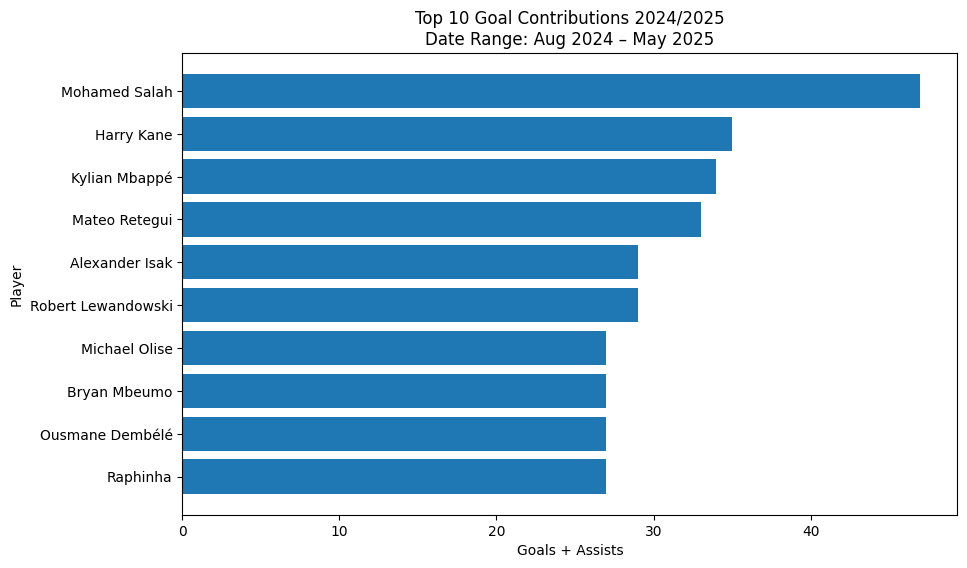

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(top_ga["Player"], top_ga["G+A"])
plt.xlabel("Goals + Assists")
plt.ylabel("Player")
plt.title("Top 10 Goal Contributions 2024/2025\nDate Range: Aug 2024 – May 2025")
plt.gca().invert_yaxis()
plt.show()

### League Comparison

In [19]:
league_summary = data.groupby("Comp").agg(
    Players=("Player", "count"),
    Avg_Age=("Age", "mean"),
    Total_Goals=("Gls", "sum"),
    Total_Assists=("Ast", "sum"),
    Avg_Minutes=("Min", "mean")
).sort_values("Total_Goals", ascending=False)

league_summary

,Players,Avg_Age,Total_Goals,Total_Assists,Avg_Minutes
Comp,,,,,
eng Premier League,574,25.098246,1082,804,1308.240418
es La Liga,601,25.360000,969,673,1248.434276
de Bundesliga,492,25.230612,934,671,1228.337398
it Serie A,634,25.241325,933,667,1180.061514
fr Ligue 1,553,24.123188,885,612,1092.159132


### Position Analysis

In [20]:
position_summary = data.groupby("Pos").agg(
    Players=("Player", "count"),
    Avg_Age=("Age", "mean"),
    Total_Goals=("Gls", "sum"),
    Total_Assists=("Ast", "sum"),
    Avg_Minutes=("Min", "mean")
).sort_values("Total_Goals", ascending=False)

position_summary.head(15)

,Players,Avg_Age,Total_Goals,Total_Assists,Avg_Minutes
Pos,,,,,
FW,371,24.666667,1683,600,1025.016173
"FW,MF",325,24.343653,998,649,1064.255385
MF,589,24.724490,769,721,1180.349745
"MF,FW",230,23.917031,530,424,1057.234783
DF,859,25.373396,529,659,1369.860303
"MF,DF",81,24.481481,110,133,1286.728395
"DF,MF",110,24.745455,105,149,1165.372727
"DF,FW",53,24.169811,53,61,1079.509434
"FW,DF",24,24.083333,26,14,485.583333


### Young Talent Analysis

In [21]:
young_players = data_900[data_900["Age"] <= 21].copy()

top_young = young_players.sort_values("G+A", ascending=False).head(10)

top_young[["Player", "Squad", "Comp", "Pos", "Age", "Min", "Gls", "Ast", "G+A"]]

,Player,Squad,Comp,Pos,Age,Min,Gls,Ast,G+A
238,Bradley Barcola,Paris S-G,fr Ligue 1,FW,21.0,2181,14,10,24
2779,Florian Wirtz,Leverkusen,de Bundesliga,"MF,FW",21.0,2351,10,12,22
2792,Lamine Yamal,Barcelona,es La Liga,FW,17.0,2856,9,13,22
541,Rayan Cherki,Lyon,fr Ligue 1,"FW,MF",20.0,2041,8,11,19
2400,Benjamin Šeško,RB Leipzig,de Bundesliga,"FW,MF",21.0,2380,13,5,18
288,Jude Bellingham,Real Madrid,es La Liga,MF,21.0,2488,9,8,17
839,Emanuel Emegha,Strasbourg,fr Ligue 1,FW,21.0,2293,14,3,17
2428,Xavi Simons,RB Leipzig,de Bundesliga,MF,21.0,2150,10,6,16
2496,Lucas Stassin,Saint-Étienne,fr Ligue 1,FW,19.0,1887,12,4,16
330,Mika Biereth,Monaco,fr Ligue 1,FW,21.0,1228,13,2,15


### Passing Analysis

In [26]:
cols = [
    "Player", "Nation", "Pos", "Squad", "Comp", "Age",
    "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A",
    "xG", "xAG", "G-xG",
    "Sh", "SoT", "SoT%",
    "PrgC", "PrgP", "PrgR",
    "Cmp", "Att", "Cmp%",
    "Tkl", "Int", "Tkl+Int"
]

data = df[cols].copy()

data_900 = data[data["Min"] >= 900].copy()

In [27]:
passing_players = data_900[data_900["Att"] >= 500].copy()

top_passing = passing_players.sort_values("Cmp%", ascending=False).head(10)

top_passing[["Player", "Squad", "Comp", "Pos", "Att", "Cmp", "Cmp%"]]

,Player,Squad,Comp,Pos,Att,Cmp,Cmp%
980,Federico Gatti,Juventus,it Serie A,DF,1460,1387,95.0
1633,Marquinhos,Paris S-G,fr Ligue 1,DF,1830,1736,94.9
2019,Willian Pacho,Paris S-G,fr Ligue 1,DF,1968,1865,94.8
1274,Frenkie de Jong,Barcelona,es La Liga,MF,1148,1084,94.4
305,Lucas Beraldo,Paris S-G,fr Ligue 1,DF,2132,2013,94.4
2310,William Saliba,Arsenal,eng Premier League,DF,2559,2413,94.3
516,Dani Ceballos,Real Madrid,es La Liga,MF,1361,1284,94.3
1720,Ferland Mendy,Real Madrid,es La Liga,DF,671,630,93.9
2651,Dayot Upamecano,Bayern Munich,de Bundesliga,DF,1923,1805,93.9
163,Raúl Asencio,Real Madrid,es La Liga,DF,988,927,93.8


### Defensive Analysis

In [23]:
top_defensive = data_900.sort_values("Tkl+Int", ascending=False).head(10)

top_defensive[["Player", "Squad", "Comp", "Pos", "Min", "Tkl", "Int", "Tkl+Int"]]

,Player,Squad,Comp,Pos,Min,Tkl,Int,Tkl+Int
962,Idrissa Gana Gueye,Everton,eng Premier League,MF,3063,133,48,181
1823,Daniel Muñoz,Crystal Palace,eng Premier League,DF,3228,123,44,167
434,Moisés Caicedo,Chelsea,eng Premier League,"MF,DF",3351,114,49,163
1161,Omar El Hilali,Espanyol,es La Liga,DF,3153,111,46,157
2223,Antonee Robinson,Fulham,eng Premier League,DF,3167,95,62,157
125,Benjamin André,Lille,fr Ligue 1,MF,2692,103,48,151
489,Carmona,Sevilla,es La Liga,DF,2942,83,68,151
935,Morten Frendrup,Genoa,it Serie A,MF,3103,102,47,149
1685,Noussair Mazraoui,Manchester Utd,eng Premier League,DF,2838,115,34,149
2568,Nahuel Tenaglia,Alavés,es La Liga,DF,2922,96,47,143


### Player Efficiency per 90 min.

In [24]:
data_900["Gls_per90"] = data_900["Gls"] / data_900["90s"]
data_900["Ast_per90"] = data_900["Ast"] / data_900["90s"]
data_900["GA_per90"] = data_900["G+A"] / data_900["90s"]

top_efficiency = data_900.sort_values("GA_per90", ascending=False).head(10)

top_efficiency[["Player", "Squad", "Comp", "Pos", "Min", "Gls", "Ast", "GA_per90"]]

,Player,Squad,Comp,Pos,Min,Gls,Ast,GA_per90
1631,Omar Marmoush,Eint Frankfurt,de Bundesliga,FW,1448,15,9,1.490683
697,Ousmane Dembélé,Paris S-G,fr Ligue 1,FW,1730,21,6,1.406250
1317,Harry Kane,Bayern Munich,de Bundesliga,FW,2381,26,9,1.320755
2612,Ferrán Torres,Barcelona,es La Liga,"FW,MF",1106,10,6,1.300813
2539,Alexander Sørloth,Atlético Madrid,es La Liga,FW,1566,20,2,1.264368
2304,Mohamed Salah,Liverpool,eng Premier League,FW,3371,29,18,1.253333
2201,Mateo Retegui,Atalanta,it Serie A,FW,2383,25,8,1.245283
2369,Patrik Schick,Leverkusen,de Bundesliga,FW,1684,21,0,1.122995
1047,Amine Gouiri,Marseille,fr Ligue 1,"FW,MF",1048,10,3,1.120690
330,Mika Biereth,Monaco,fr Ligue 1,FW,1228,13,2,1.102941


### Create Player Performance Score

In [25]:
from sklearn.preprocessing import MinMaxScaler

score_cols = ["Gls", "Ast", "xG", "xAG", "PrgC", "PrgP", "PrgR"]

score_data = data_900[score_cols].fillna(0)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(score_data)

data_900["Performance_Score"] = scaled.mean(axis=1)

top_score = data_900.sort_values("Performance_Score", ascending=False).head(10)

top_score[["Player", "Squad", "Comp", "Pos", "Gls", "Ast", "xG", "xAG", "Performance_Score"]]

,Player,Squad,Comp,Pos,Gls,Ast,xG,xAG,Performance_Score
2304,Mohamed Salah,Liverpool,eng Premier League,FW,29,18,25.2,14.2,0.855167
1691,Kylian Mbappé,Real Madrid,es La Liga,FW,31,3,25.9,7.7,0.649513
2792,Lamine Yamal,Barcelona,es La Liga,FW,9,13,9.8,13.9,0.647442
1960,Michael Olise,Bayern Munich,de Bundesliga,"FW,MF",12,15,9.7,12.0,0.610164
2177,Raphinha,Barcelona,es La Liga,"FW,MF",18,9,19.2,12.7,0.601844
238,Bradley Barcola,Paris S-G,fr Ligue 1,FW,14,10,13.4,10.1,0.555383
2033,Cole Palmer,Chelsea,eng Premier League,"MF,FW",15,8,17.3,10.9,0.553148
1693,Bryan Mbeumo,Brentford,eng Premier League,FW,20,7,12.3,8.3,0.541646
697,Ousmane Dembélé,Paris S-G,fr Ligue 1,FW,21,6,16.6,8.2,0.527408
1060,Mason Greenwood,Marseille,fr Ligue 1,"FW,MF",21,5,16.3,5.7,0.512549
